# Student Performance Analytics

**Objective**: Analyze student demographic, behavioral, and study-related variables to explain and predict academic performance, and identify which factors contribute most to higher achievement.

---

## 1. Data Loading & Preparation

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv('01. dataset/student_performance.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset Shape: (25000, 16)

Columns: ['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']


In [2]:
# Data overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

Total missing: 0


In [4]:
# Statistical summary - numeric variables
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [5]:
# Categorical variables summary
cat_cols = ['gender', 'school_type', 'parent_education', 'internet_access', 
            'travel_time', 'extra_activities', 'study_method', 'final_grade']

for col in cat_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts())


GENDER:
gender
other     8463
female    8290
male      8247
Name: count, dtype: int64

SCHOOL_TYPE:
school_type
private    12725
public     12275
Name: count, dtype: int64

PARENT_EDUCATION:
parent_education
diploma          4314
high school      4205
post graduate    4196
graduate         4127
no formal        4079
phd              4079
Name: count, dtype: int64

INTERNET_ACCESS:
internet_access
yes    21227
no      3773
Name: count, dtype: int64

TRAVEL_TIME:
travel_time
15-30 min    6362
30-60 min    6345
>60 min      6166
<15 min      6127
Name: count, dtype: int64

EXTRA_ACTIVITIES:
extra_activities
yes    12500
no     12500
Name: count, dtype: int64

STUDY_METHOD:
study_method
mixed            4341
textbook         4239
notes            4165
online videos    4139
group study      4090
coaching         4026
Name: count, dtype: int64

FINAL_GRADE:
final_grade
d    6311
c    6161
e    5672
f    2955
b    2696
a    1205
Name: count, dtype: int64


## 2. Exploratory Data Analysis

### 2.1 Target Variable Distributions

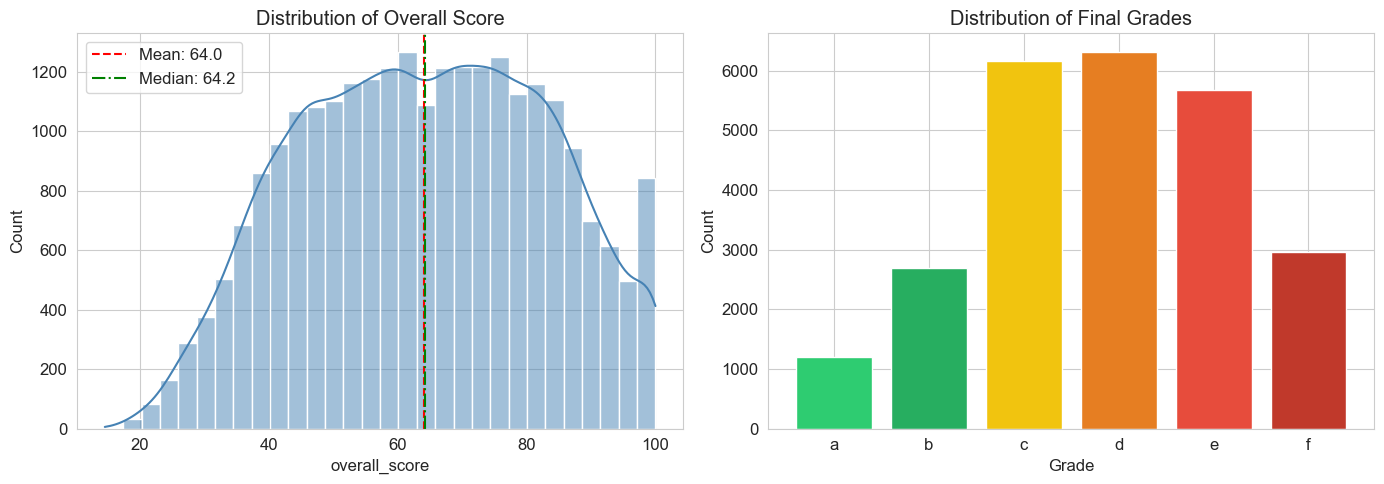


Grade Distribution (%):
final_grade
d    25.2
c    24.6
e    22.7
f    11.8
b    10.8
a     4.8
Name: proportion, dtype: float64


In [6]:
# Overall Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['overall_score'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(df['overall_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['overall_score'].mean():.1f}")
axes[0].axvline(df['overall_score'].median(), color='green', linestyle='-.', label=f"Median: {df['overall_score'].median():.1f}")
axes[0].set_title('Distribution of Overall Score')
axes[0].legend()

# Final Grade Distribution
grade_order = ['a', 'b', 'c', 'd', 'e', 'f']
grade_counts = df['final_grade'].value_counts().reindex(grade_order)
colors = ['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']
axes[1].bar(grade_order, grade_counts, color=colors, edgecolor='white')
axes[1].set_title('Distribution of Final Grades')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nGrade Distribution (%):\n{(df['final_grade'].value_counts(normalize=True)*100).round(1)}")

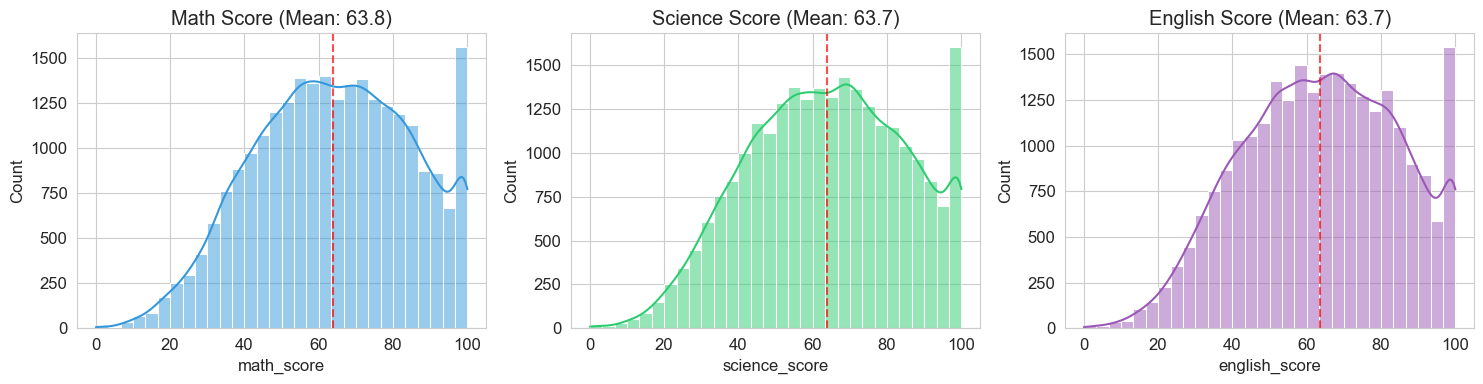

In [7]:
# Subject Score Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ['math_score', 'science_score', 'english_score'], 
                          ['#3498db', '#2ecc71', '#9b59b6']):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color=color)
    ax.axvline(df[col].mean(), color='red', linestyle='--', alpha=0.7)
    ax.set_title(f'{col.replace("_", " ").title()} (Mean: {df[col].mean():.1f})')

plt.tight_layout()
plt.show()

### 2.2 Study Habits vs. Performance

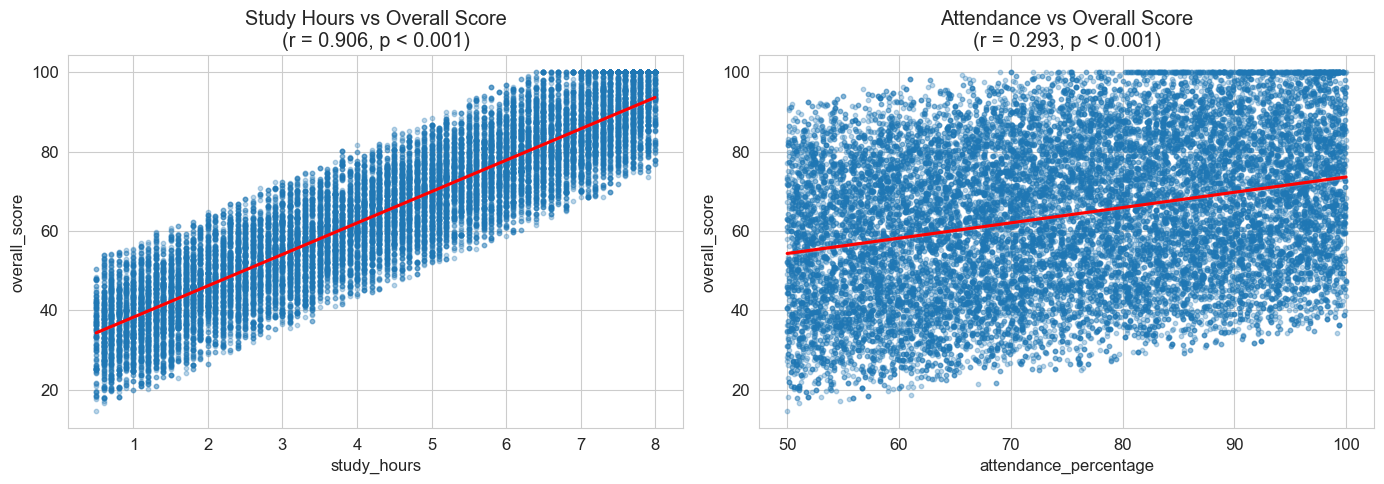

In [8]:
# Study Hours and Attendance vs Overall Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Study Hours
sns.regplot(x='study_hours', y='overall_score', data=df, ax=axes[0], 
            scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
r, p = pearsonr(df['study_hours'], df['overall_score'])
axes[0].set_title(f'Study Hours vs Overall Score\n(r = {r:.3f}, p < 0.001)')

# Attendance
sns.regplot(x='attendance_percentage', y='overall_score', data=df, ax=axes[1],
            scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
r, p = pearsonr(df['attendance_percentage'], df['overall_score'])
axes[1].set_title(f'Attendance vs Overall Score\n(r = {r:.3f}, p < 0.001)')

plt.tight_layout()
plt.show()

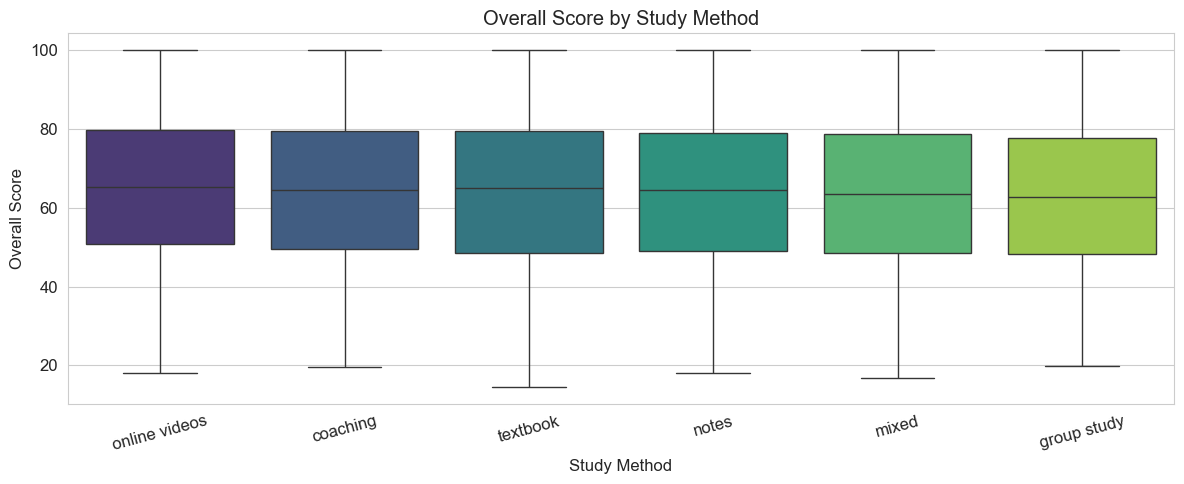


Mean Score by Study Method:
                mean    std  count
study_method                      
online videos  64.69  18.79   4139
coaching       64.37  18.94   4026
textbook       64.24  19.25   4239
notes          63.90  18.70   4165
mixed          63.61  18.90   4341
group study    63.25  18.99   4090


In [9]:
# Study Method Effectiveness
fig, ax = plt.subplots(figsize=(12, 5))

method_order = df.groupby('study_method')['overall_score'].mean().sort_values(ascending=False).index
sns.boxplot(x='study_method', y='overall_score', data=df, order=method_order, palette='viridis', ax=ax)
ax.set_title('Overall Score by Study Method')
ax.set_xlabel('Study Method')
ax.set_ylabel('Overall Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nMean Score by Study Method:")
print(df.groupby('study_method')['overall_score'].agg(['mean', 'std', 'count']).round(2).sort_values('mean', ascending=False))

### 2.3 Demographics vs. Performance

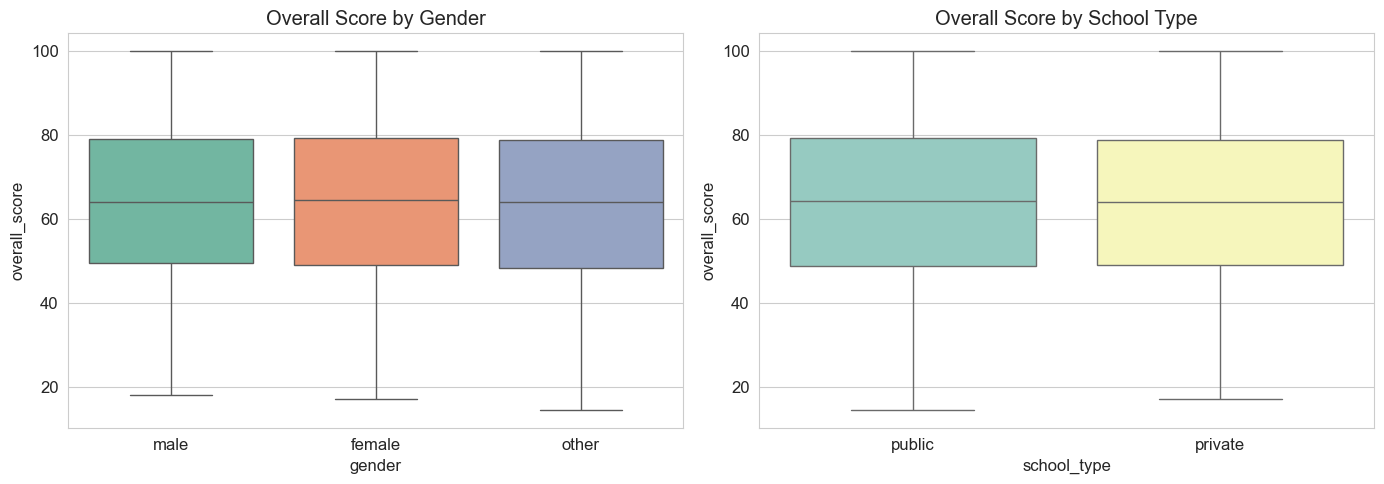

In [10]:
# Gender and School Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='gender', y='overall_score', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Overall Score by Gender')

sns.boxplot(x='school_type', y='overall_score', data=df, palette='Set3', ax=axes[1])
axes[1].set_title('Overall Score by School Type')

plt.tight_layout()
plt.show()

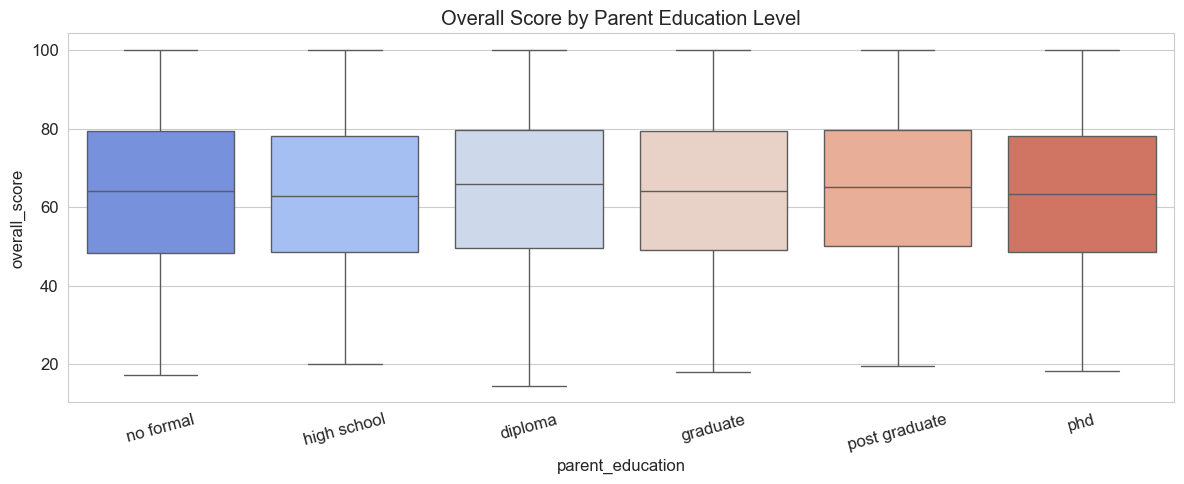


Mean Score by Parent Education:
parent_education
no formal        63.91
high school      63.39
diploma          64.65
graduate         63.96
post graduate    64.56
phd              63.54
Name: overall_score, dtype: float64


In [11]:
# Parent Education Impact
edu_order = ['no formal', 'high school', 'diploma', 'graduate', 'post graduate', 'phd']

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x='parent_education', y='overall_score', data=df, order=edu_order, palette='coolwarm', ax=ax)
ax.set_title('Overall Score by Parent Education Level')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nMean Score by Parent Education:")
print(df.groupby('parent_education')['overall_score'].mean().reindex(edu_order).round(2))

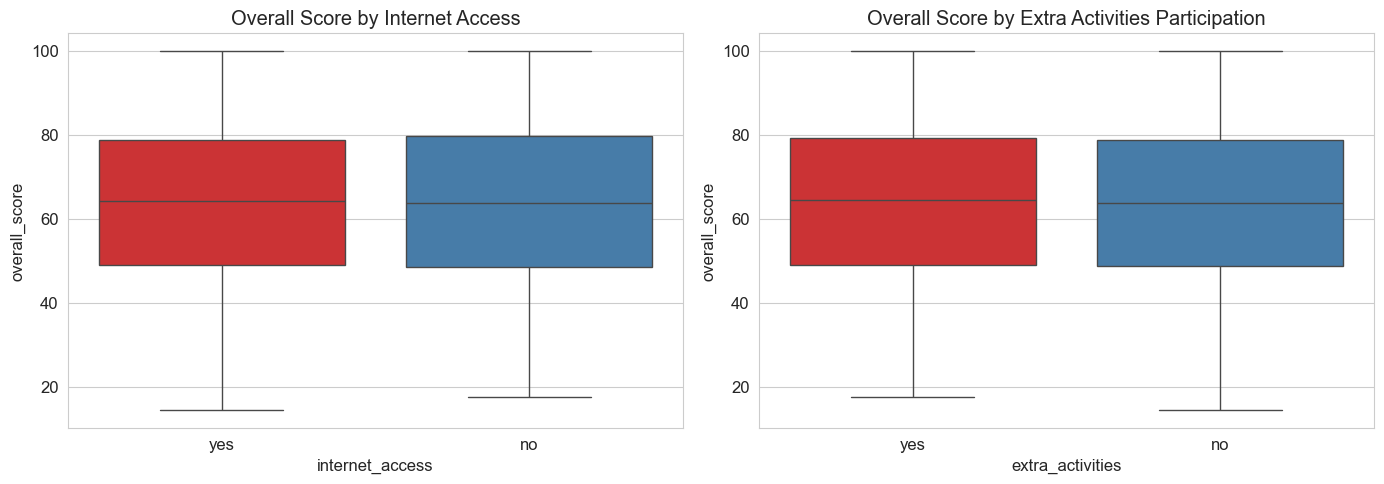

In [12]:
# Internet Access and Extra Activities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='internet_access', y='overall_score', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Overall Score by Internet Access')

sns.boxplot(x='extra_activities', y='overall_score', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Overall Score by Extra Activities Participation')

plt.tight_layout()
plt.show()

### 2.4 Correlation Analysis

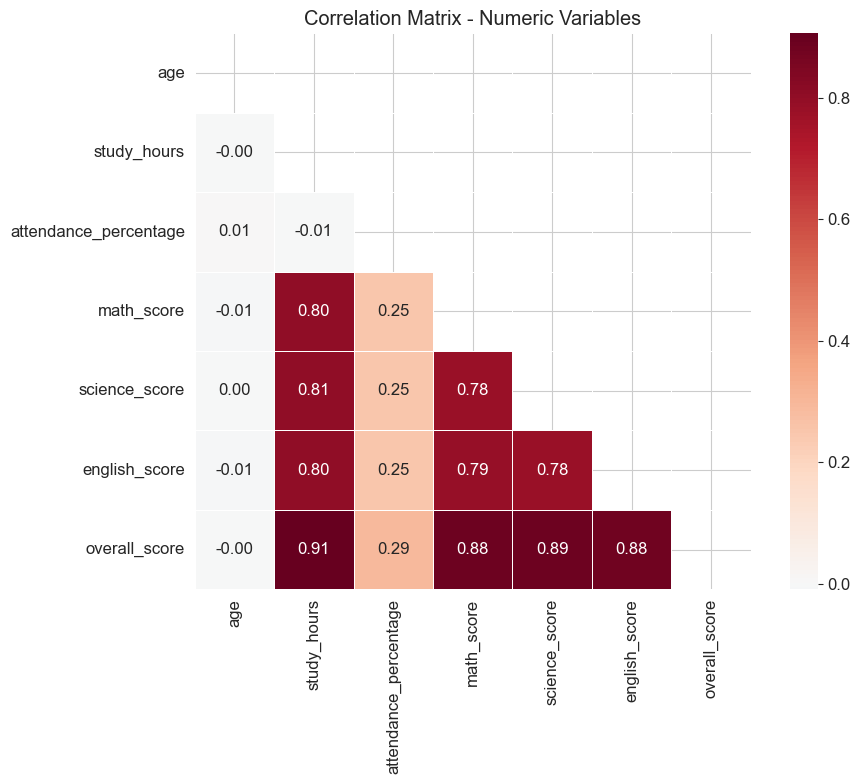

In [13]:
# Correlation Heatmap
numeric_cols = ['age', 'study_hours', 'attendance_percentage', 'math_score', 
                'science_score', 'english_score', 'overall_score']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix - Numeric Variables')
plt.tight_layout()
plt.show()

## 3. Statistical Analysis

### 3.1 Correlation with Overall Score

In [14]:
# Correlation coefficients with overall_score
print("Correlation with Overall Score:")
print("="*50)

for col in ['study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score']:
    r, p = pearsonr(df[col], df['overall_score'])
    print(f"{col:25} r = {r:.4f}, p-value = {p:.2e}")

Correlation with Overall Score:
study_hours               r = 0.9058, p-value = 0.00e+00
attendance_percentage     r = 0.2928, p-value = 0.00e+00
math_score                r = 0.8846, p-value = 0.00e+00
science_score             r = 0.8857, p-value = 0.00e+00
english_score             r = 0.8833, p-value = 0.00e+00


### 3.2 T-Tests for Binary Variables

In [15]:
# Internet Access T-Test
internet_yes = df[df['internet_access'] == 'yes']['overall_score']
internet_no = df[df['internet_access'] == 'no']['overall_score']

t_stat, p_val = ttest_ind(internet_yes, internet_no)
cohens_d = (internet_yes.mean() - internet_no.mean()) / np.sqrt((internet_yes.std()**2 + internet_no.std()**2) / 2)

print("INTERNET ACCESS IMPACT ON OVERALL SCORE")
print("="*50)
print(f"With Internet:    Mean = {internet_yes.mean():.2f}, SD = {internet_yes.std():.2f}, n = {len(internet_yes)}")
print(f"Without Internet: Mean = {internet_no.mean():.2f}, SD = {internet_no.std():.2f}, n = {len(internet_no)}")
print(f"\nt-statistic = {t_stat:.3f}")
print(f"p-value = {p_val:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")
print(f"\nInterpretation: {'Significant difference' if p_val < 0.05 else 'No significant difference'}")

INTERNET ACCESS IMPACT ON OVERALL SCORE
With Internet:    Mean = 64.05, SD = 18.87, n = 21227
Without Internet: Mean = 63.77, SD = 19.27, n = 3773

t-statistic = 0.815
p-value = 0.4153
Cohen's d = 0.014

Interpretation: No significant difference


In [31]:
# Extra Activities T-Test
extra_yes = df[df['extra_activities'] == 'yes']['overall_score']
extra_no = df[df['extra_activities'] == 'no']['overall_score']

t_stat, p_val = ttest_ind(extra_yes, extra_no)
cohens_d = (extra_yes.mean() - extra_no.mean()) / np.sqrt((extra_yes.std()**2 + extra_no.std()**2) / 2)

print("EXTRA ACTIVITIES IMPACT ON OVERALL SCORE")
print("="*50)
print(f"With Extra Activities:    Mean = {extra_yes.mean():.2f}, SD = {extra_yes.std():.2f}, n = {len(extra_yes)}")
print(f"Without Extra Activities: Mean = {extra_no.mean():.2f}, SD = {extra_no.std():.2f}, n = {len(extra_no)}")
print(f"\nt-statistic = {t_stat:.3f}")
print(f"p-value = {p_val:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")
print(f"\nInterpretation: {'Significant difference' if p_val < 0.05 else 'No significant difference'}")

EXTRA ACTIVITIES IMPACT ON OVERALL SCORE
With Extra Activities:    Mean = 64.15, SD = 18.96, n = 12500
Without Extra Activities: Mean = 63.86, SD = 18.90, n = 12500

t-statistic = 1.201
p-value = 0.2298
Cohen's d = 0.015

Interpretation: No significant difference


In [32]:
# School Type T-Test
public = df[df['school_type'] == 'public']['overall_score']
private = df[df['school_type'] == 'private']['overall_score']

t_stat, p_val = ttest_ind(public, private)
cohens_d = (public.mean() - private.mean()) / np.sqrt((public.std()**2 + private.std()**2) / 2)

print("SCHOOL TYPE IMPACT ON OVERALL SCORE")
print("="*50)
print(f"Public School:  Mean = {public.mean():.2f}, SD = {public.std():.2f}, n = {len(public)}")
print(f"Private School: Mean = {private.mean():.2f}, SD = {private.std():.2f}, n = {len(private)}")
print(f"\nt-statistic = {t_stat:.3f}")
print(f"p-value = {p_val:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")
print(f"\nInterpretation: {'Significant difference' if p_val < 0.05 else 'No significant difference'}")

SCHOOL TYPE IMPACT ON OVERALL SCORE
Public School:  Mean = 64.03, SD = 18.99, n = 12275
Private School: Mean = 63.99, SD = 18.87, n = 12725

t-statistic = 0.178
p-value = 0.8586
Cohen's d = 0.002

Interpretation: No significant difference


### 3.3 ANOVA for Parent Education

In [18]:
# One-way ANOVA for Parent Education
edu_groups = [df[df['parent_education'] == edu]['overall_score'] for edu in edu_order]

f_stat, p_val = f_oneway(*edu_groups)

print("PARENT EDUCATION IMPACT ON OVERALL SCORE (ANOVA)")
print("="*50)
print(f"F-statistic = {f_stat:.3f}")
print(f"p-value = {p_val:.2e}")
print(f"\nInterpretation: {'Significant differences exist between groups' if p_val < 0.05 else 'No significant difference'}")

PARENT EDUCATION IMPACT ON OVERALL SCORE (ANOVA)
F-statistic = 3.156
p-value = 7.51e-03

Interpretation: Significant differences exist between groups


### 3.4 Chi-Square Test for Grades

In [19]:
# Chi-square: Internet Access vs Final Grade
contingency = pd.crosstab(df['internet_access'], df['final_grade'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("CHI-SQUARE TEST: Internet Access vs Final Grade")
print("="*50)
print(f"Chi-square statistic = {chi2:.3f}")
print(f"p-value = {p:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"\nContingency Table:")
print(contingency)

CHI-SQUARE TEST: Internet Access vs Final Grade
Chi-square statistic = 37.947
p-value = 0.0000
Degrees of freedom = 5

Contingency Table:
final_grade         a     b     c     d     e     f
internet_access                                    
no                167   455   936   820   925   470
yes              1038  2241  5225  5491  4747  2485


## 4. Predictive Modeling - Regression

In [20]:
# Import ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("ML libraries imported successfully!")

ML libraries imported successfully!


In [21]:
# Prepare data for modeling
df_model = df.copy()

# Encode categorical variables
label_encoders = {}
cat_features = ['gender', 'school_type', 'parent_education', 'internet_access', 
                'travel_time', 'extra_activities', 'study_method']

for col in cat_features:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Features for regression (excluding subject scores - they would be "data leakage")
feature_cols = ['age', 'study_hours', 'attendance_percentage'] + \
               [col + '_encoded' for col in cat_features]

X = df_model[feature_cols]
y = df_model['overall_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {feature_cols}")

Training set: 20000 samples
Test set: 5000 samples
Features: ['age', 'study_hours', 'attendance_percentage', 'gender_encoded', 'school_type_encoded', 'parent_education_encoded', 'internet_access_encoded', 'travel_time_encoded', 'extra_activities_encoded', 'study_method_encoded']


In [22]:
# Train and evaluate regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    results.append({
        'Model': name,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae,
        'CV R² (mean)': cv_scores.mean(),
        'CV R² (std)': cv_scores.std()
    })

results_df = pd.DataFrame(results)
print("REGRESSION MODEL COMPARISON")
print("="*80)
print(results_df.round(4).to_string(index=False))

REGRESSION MODEL COMPARISON
            Model     R²   RMSE    MAE  CV R² (mean)  CV R² (std)
Linear Regression 0.9080 5.7804 5.0103        0.9088       0.0014
 Ridge Regression 0.9080 5.7804 5.0103        0.9088       0.0014
    Random Forest 0.9432 4.5393 3.3366        0.9609       0.0232
Gradient Boosting 0.9090 5.7490 4.9822        0.9103       0.0019


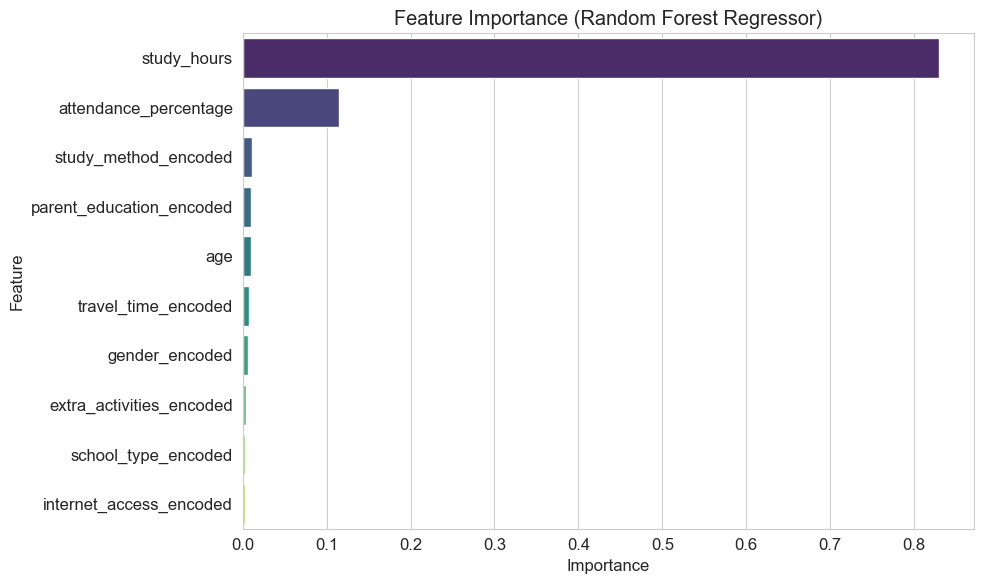


Top 5 Most Important Features:
                 Feature  Importance
             study_hours    0.829841
   attendance_percentage    0.115354
    study_method_encoded    0.010638
parent_education_encoded    0.010476
                     age    0.010408


In [23]:
# Feature Importance from Random Forest
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', ax=ax)
ax.set_title('Feature Importance (Random Forest Regressor)')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importance_df.head().to_string(index=False))

## 5. Predictive Modeling - Classification

In [24]:
# Import classification libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Create binary target: at-risk students (grades d, e, f)
df_model['at_risk'] = df_model['final_grade'].isin(['d', 'e', 'f']).astype(int)

print(f"At-Risk Students: {df_model['at_risk'].sum()} ({df_model['at_risk'].mean()*100:.1f}%)")
print(f"Not At-Risk: {(df_model['at_risk']==0).sum()} ({(1-df_model['at_risk'].mean())*100:.1f}%)")

At-Risk Students: 14938 (59.8%)
Not At-Risk: 10062 (40.2%)


In [25]:
# Prepare classification data
X_class = df_model[feature_cols]
y_class = df_model['at_risk']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(f"Training set: {X_train_c.shape[0]} samples")
print(f"Test set: {X_test_c.shape[0]} samples")

Training set: 20000 samples
Test set: 5000 samples


In [26]:
# Train and evaluate classification models
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

class_results = []

for name, clf in classifiers.items():
    clf.fit(X_train_c, y_train_c)
    y_pred_c = clf.predict(X_test_c)
    y_prob = clf.predict_proba(X_test_c)[:, 1]
    
    acc = accuracy_score(y_test_c, y_pred_c)
    auc = roc_auc_score(y_test_c, y_prob)
    
    class_results.append({
        'Model': name,
        'Accuracy': acc,
        'ROC-AUC': auc
    })

class_results_df = pd.DataFrame(class_results)
print("CLASSIFICATION MODEL COMPARISON (At-Risk Prediction)")
print("="*60)
print(class_results_df.round(4).to_string(index=False))

CLASSIFICATION MODEL COMPARISON (At-Risk Prediction)
              Model  Accuracy  ROC-AUC
Logistic Regression    0.9112   0.9790
      Random Forest    0.9612   0.9949
  Gradient Boosting    0.9148   0.9800


In [27]:
# Best model detailed report
best_clf = classifiers['Random Forest']
y_pred_best = best_clf.predict(X_test_c)

print("CLASSIFICATION REPORT (Random Forest)")
print("="*60)
print(classification_report(y_test_c, y_pred_best, target_names=['Not At-Risk', 'At-Risk']))

CLASSIFICATION REPORT (Random Forest)
              precision    recall  f1-score   support

 Not At-Risk       0.95      0.95      0.95      2012
     At-Risk       0.97      0.97      0.97      2988

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000



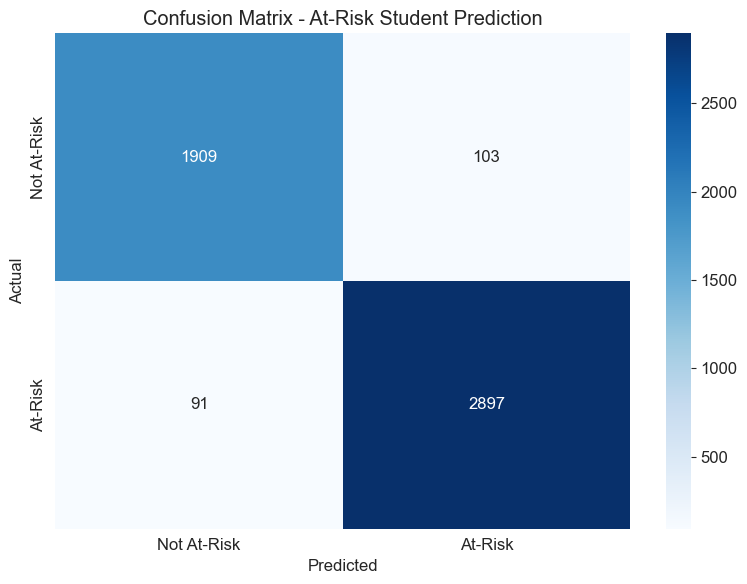

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not At-Risk', 'At-Risk'],
            yticklabels=['Not At-Risk', 'At-Risk'], ax=ax)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title('Confusion Matrix - At-Risk Student Prediction')
plt.tight_layout()
plt.show()

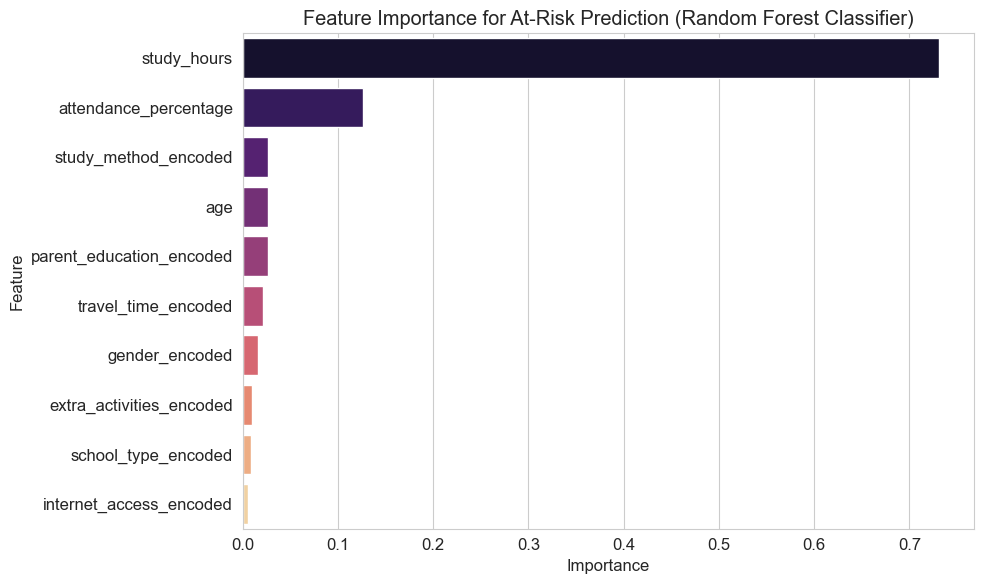


Top 5 Predictors of At-Risk Status:
                 Feature  Importance
             study_hours    0.731302
   attendance_percentage    0.126595
    study_method_encoded    0.026927
                     age    0.026853
parent_education_encoded    0.026543


In [29]:
# Feature Importance for Classification
rf_clf = classifiers['Random Forest']
clf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=clf_importance, palette='magma', ax=ax)
ax.set_title('Feature Importance for At-Risk Prediction (Random Forest Classifier)')
plt.tight_layout()
plt.show()

print("\nTop 5 Predictors of At-Risk Status:")
print(clf_importance.head().to_string(index=False))

## 6. Key Findings Summary

In [30]:
print("="*70)
print("KEY FINDINGS - STUDENT PERFORMANCE ANALYTICS")
print("="*70)

print("\n📊 DESCRIPTIVE STATISTICS:")
print(f"   • Average overall score: {df['overall_score'].mean():.1f} (SD: {df['overall_score'].std():.1f})")
print(f"   • At-risk students (grades D, E, F): {(df['final_grade'].isin(['d','e','f']).mean()*100):.1f}%")

print("\n📈 CORRELATION ANALYSIS:")
r_study, _ = pearsonr(df['study_hours'], df['overall_score'])
r_att, _ = pearsonr(df['attendance_percentage'], df['overall_score'])
print(f"   • Study hours ↔ Overall score: r = {r_study:.3f}")
print(f"   • Attendance ↔ Overall score: r = {r_att:.3f}")

print("\n🎯 PREDICTIVE MODELS:")
print(f"   • Best Regression Model: {results_df.loc[results_df['R²'].idxmax(), 'Model']}")
print(f"     R² = {results_df['R²'].max():.3f}")
print(f"   • Best Classification Model: Random Forest")
print(f"     ROC-AUC = {class_results_df.loc[class_results_df['ROC-AUC'].idxmax(), 'ROC-AUC']:.3f}")

print("\n🔑 TOP PREDICTORS OF ACADEMIC SUCCESS:")
for i, row in importance_df.head(5).iterrows():
    print(f"   {importance_df.index.get_loc(i)+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "="*70)

KEY FINDINGS - STUDENT PERFORMANCE ANALYTICS

📊 DESCRIPTIVE STATISTICS:
   • Average overall score: 64.0 (SD: 18.9)
   • At-risk students (grades D, E, F): 59.8%

📈 CORRELATION ANALYSIS:
   • Study hours ↔ Overall score: r = 0.906
   • Attendance ↔ Overall score: r = 0.293

🎯 PREDICTIVE MODELS:
   • Best Regression Model: Random Forest
     R² = 0.943
   • Best Classification Model: Random Forest
     ROC-AUC = 0.995

🔑 TOP PREDICTORS OF ACADEMIC SUCCESS:
   1. study_hours: 0.8298
   2. attendance_percentage: 0.1154
   3. study_method_encoded: 0.0106
   4. parent_education_encoded: 0.0105
   5. age: 0.0104

